# PE-AV-small-16-frame

## joint

### notnormalized_global_delay5s/2s

#### Gradient

Loaded Left Alignment: 32492 vertices
Loaded Right Alignment: 32492 vertices
Processing Gradient 1...
Spearman Correlation (Global Cortex): ρ = 0.201, p = 0.000e+00


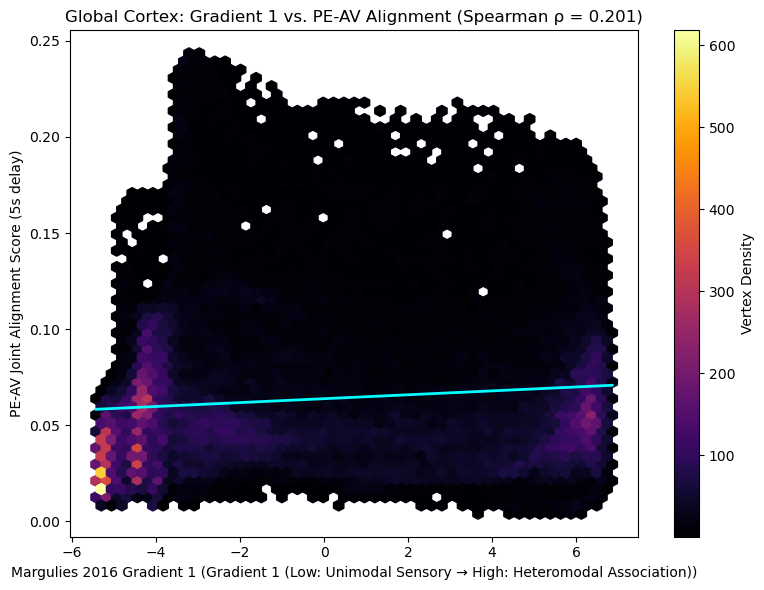

Processing Gradient 2...
Spearman Correlation (Global Cortex): ρ = 0.145, p = 6.345e-276


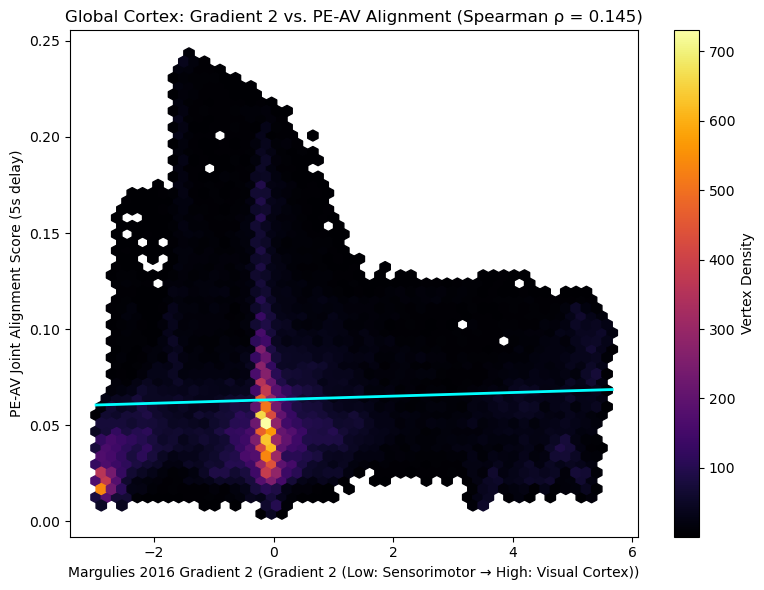

Processing Gradient 3...
Spearman Correlation (Global Cortex): ρ = -0.212, p = 0.000e+00


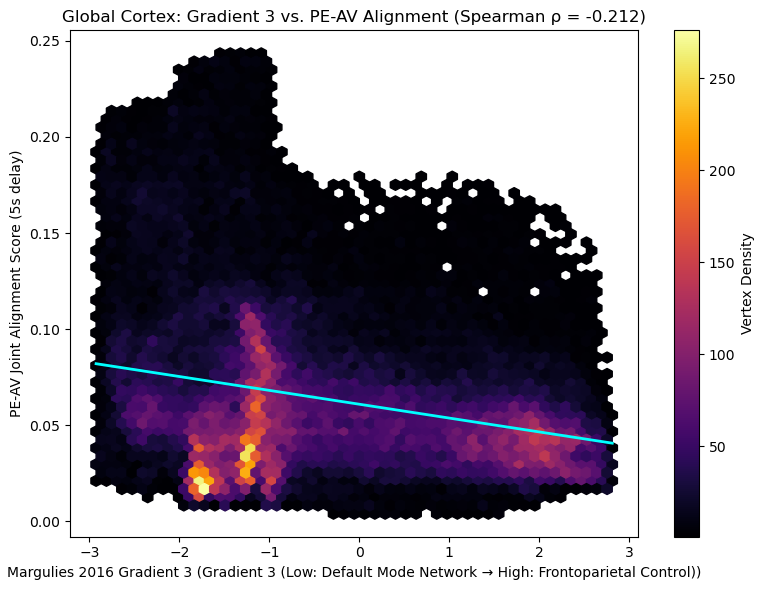

Processing Gradient 4...
Spearman Correlation (Global Cortex): ρ = 0.112, p = 8.270e-165


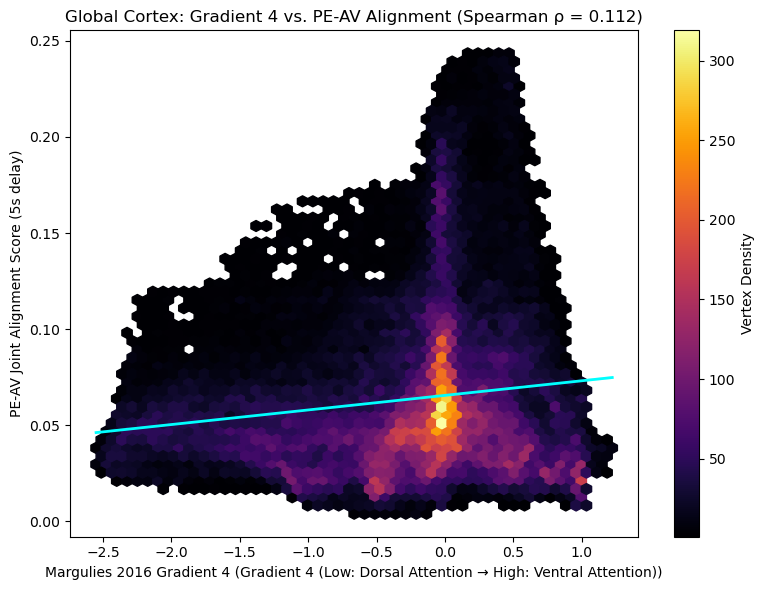

Processing Gradient 5...
Spearman Correlation (Global Cortex): ρ = 0.487, p = 0.000e+00


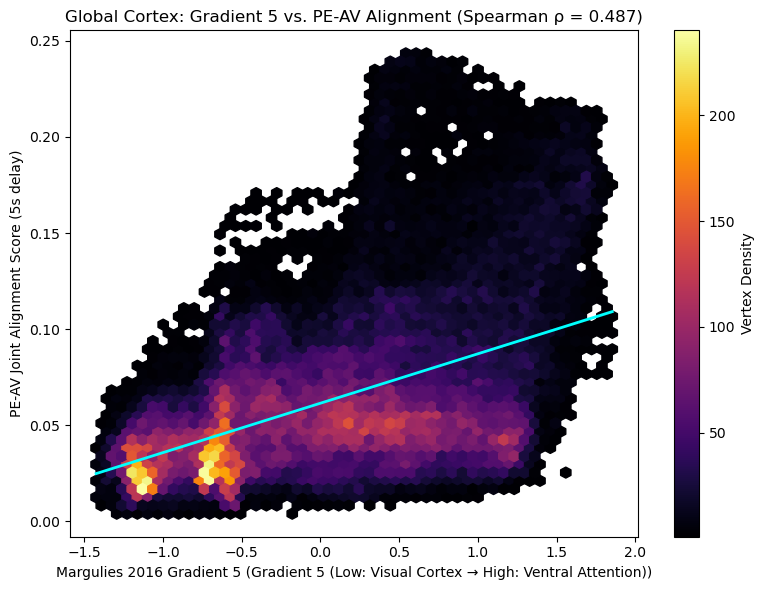

Processing Gradient 6...
Spearman Correlation (Global Cortex): ρ = -0.186, p = 0.000e+00


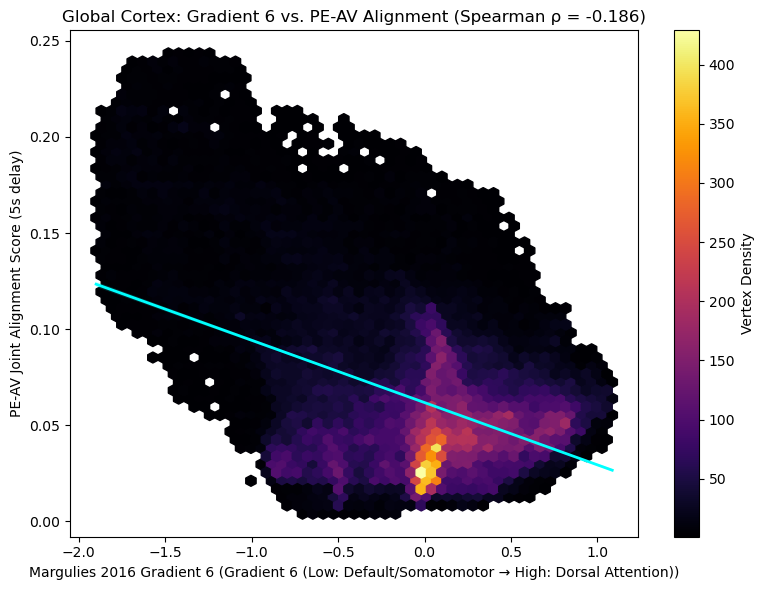

Processing Gradient 7...
Spearman Correlation (Global Cortex): ρ = -0.187, p = 0.000e+00


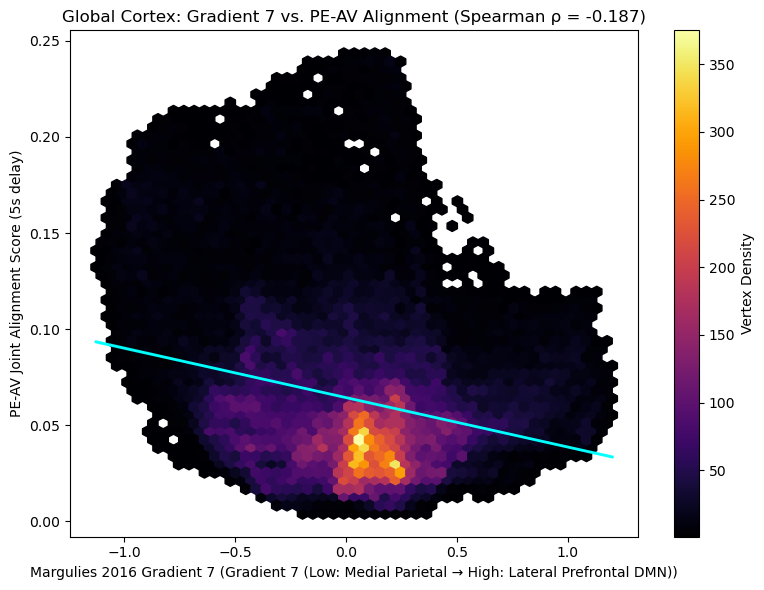

Processing Gradient 8...
Spearman Correlation (Global Cortex): ρ = 0.156, p = 0.000e+00


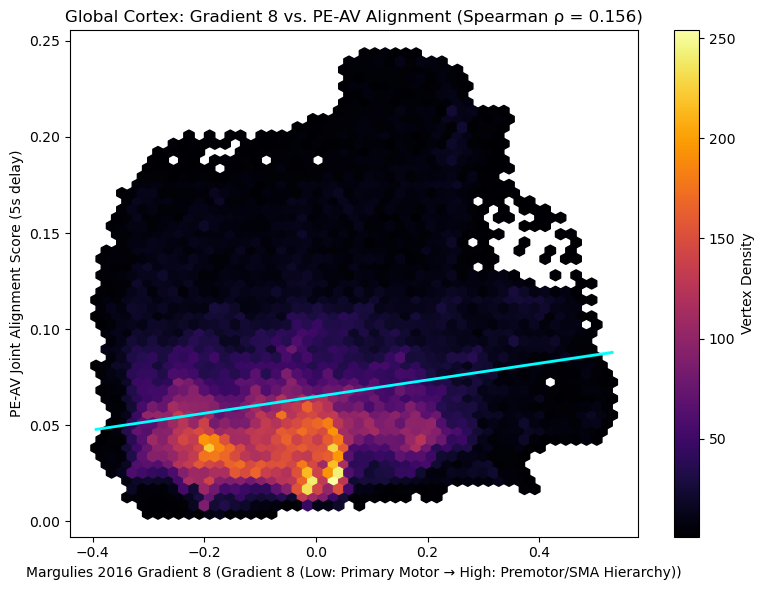

Processing Gradient 9...
Spearman Correlation (Global Cortex): ρ = -0.189, p = 0.000e+00


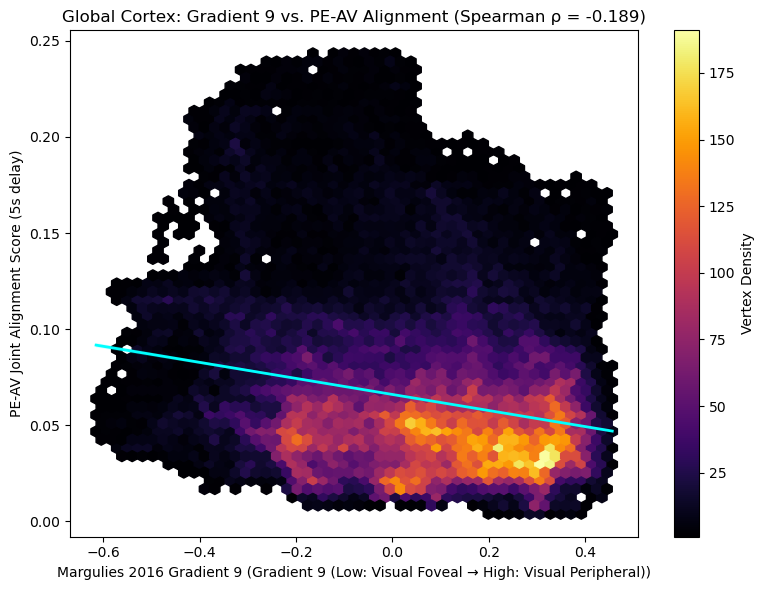

Processing Gradient 10...
Spearman Correlation (Global Cortex): ρ = -0.188, p = 0.000e+00


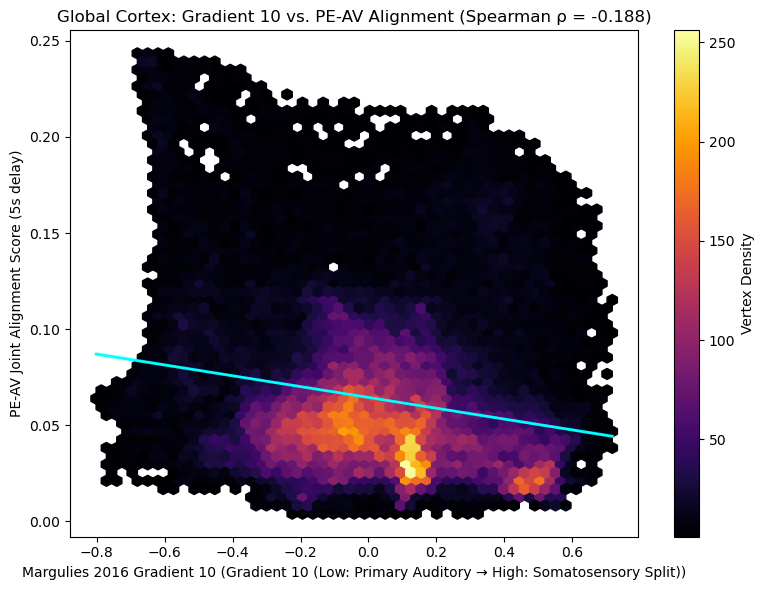

In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr



# ---------------------------------------------------------
# 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
# ---------------------------------------------------------
left_npy_path = '/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_notnormalized_global_delay5s/2s/joint/left_hemisphere/rsa_pe-av-small-16-frame_joint_k100_spearman_notnormalized_nohrf_bin2s_left_global.npy'
right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

align_L_raw = np.load(left_npy_path)
align_R_raw = np.load(right_npy_path)

print(f"Loaded Left Alignment: {align_L_raw.shape[0]} vertices")
print(f"Loaded Right Alignment: {align_R_raw.shape[0]} vertices")

gradient_descriptions = {
    1: "Gradient 1 (Low: Unimodal Sensory → High: Heteromodal Association)",
    2: "Gradient 2 (Low: Sensorimotor → High: Visual Cortex)",
    3: "Gradient 3 (Low: Default Mode Network → High: Frontoparietal Control)",
    4: "Gradient 4 (Low: Dorsal Attention → High: Ventral Attention)",
    5: "Gradient 5 (Low: Visual Cortex → High: Ventral Attention)",
    6: "Gradient 6 (Low: Default/Somatomotor → High: Dorsal Attention)",
    7: "Gradient 7 (Low: Medial Parietal → High: Lateral Prefrontal DMN)",
    8: "Gradient 8 (Low: Primary Motor → High: Premotor/SMA Hierarchy)",
    9: "Gradient 9 (Low: Visual Foveal → High: Visual Peripheral)",
    10: "Gradient 10 (Low: Primary Auditory → High: Somatosensory Split)"
}
for i in range(1, 11):
    
    print(f"Processing Gradient {i}...")
    # ---------------------------------------------------------
    # 2. LOAD LOCAL MARGULIES GRADIENTS (.gii)
    # ---------------------------------------------------------
    if i == 10:
        left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient10/fsLR/source-margulies2016_desc-fcgradient10_space-fsLR_den-32k_hemi-L_feature.func.gii'
    else:
        left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient0{i}/fsLR/source-margulies2016_desc-fcgradient0{i}_space-fsLR_den-32k_hemi-L_feature.func.gii'
    right_gii_path = left_gii_path.replace('hemi-L', 'hemi-R')

    grad1_L_raw = nib.load(left_gii_path).agg_data()
    grad1_R_raw = nib.load(right_gii_path).agg_data()

    # ---------------------------------------------------------
    # 3. GENERATE MEDIAL WALL MASKS & FILTER BOTH
    # ---------------------------------------------------------
    # We use the gradient to define where the medial wall is (NaNs or strict 0s)
    mask_L = (~np.isnan(grad1_L_raw)) & (grad1_L_raw != 0)
    mask_R = (~np.isnan(grad1_R_raw)) & (grad1_R_raw != 0)

    # Filter the gradients to cortex-only (~29k vertices)
    grad1_L_cortex = grad1_L_raw[mask_L]
    grad1_R_cortex = grad1_R_raw[mask_R]

    # Apply the exact same masks to your alignment NPYs
    align_L_cortex = align_L_raw[mask_L]
    align_R_cortex = align_R_raw[mask_R]

    # Check shapes
    assert grad1_L_cortex.shape == align_L_cortex.shape, "Left shape mismatch after masking!"
    assert grad1_R_cortex.shape == align_R_cortex.shape, "Right shape mismatch after masking!"

    # ---------------------------------------------------------
    # 4. CONCATENATE & CALCULATE CORRELATION
    # ---------------------------------------------------------
    grad1_full = np.concatenate([grad1_L_cortex, grad1_R_cortex])
    align_full = np.concatenate([align_L_cortex, align_R_cortex])

    # Final safety check for any NaNs originating from your alignment data itself
    valid_mask = ~np.isnan(align_full) & ~np.isnan(grad1_full)
    grad1_valid = grad1_full[valid_mask]
    align_valid = align_full[valid_mask]

    corr, p_val = spearmanr(grad1_valid, align_valid)
    print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

    # ---------------------------------------------------------
    # 5. CREATE THE SCATTERPLOT
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))

    plt.hexbin(grad1_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
    cb = plt.colorbar(label='Vertex Density')

    sns.regplot(x=grad1_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})
    axis_desc = gradient_descriptions.get(i, f"Variance Axis {i}")
    plt.xlabel(f'Margulies 2016 Gradient {i} ({axis_desc})')
    plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
    plt.title(f'Global Cortex: Gradient {i} vs. PE-AV Alignment (Spearman ρ = {corr:.3f})')

    plt.tight_layout()
    plt.show()

#### myelin

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Spearman Correlation (Global Cortex): ρ = -0.115, p = 1.384e-174


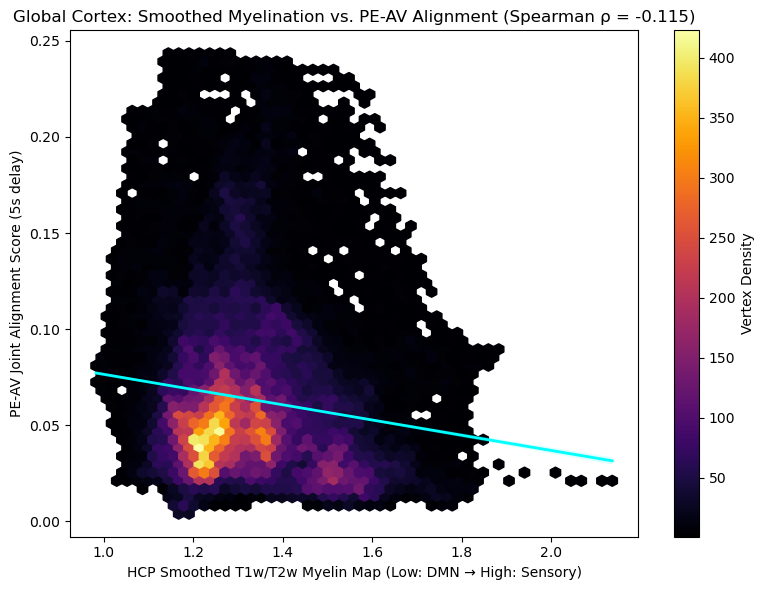

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# ---------------------------------------------------------
# 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
# ---------------------------------------------------------
left_npy_path = '/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_notnormalized_global_delay5s/2s/joint/left_hemisphere/rsa_pe-av-small-16-frame_joint_k100_spearman_notnormalized_nohrf_bin2s_left_global.npy'
right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

align_L_raw = np.load(left_npy_path)
align_R_raw = np.load(right_npy_path)

# ---------------------------------------------------------
# 2. LOAD YOUR SMOOTHED MYELIN CIFTI
# ---------------------------------------------------------
# MAKE SURE THIS PATH IS CORRECT FOR YOUR LOCAL MACHINE
myelin_cifti_path = '//home/amin/Research/Representation/Movie/data/Setareh/HCP_S1200_GroupAvg_v1/S1200.SmoothedMyelinMap_BC_MSMAll.32k_fs_LR.dscalar.nii'

myelin_cifti = nib.load(myelin_cifti_path)
myelin_data = myelin_cifti.get_fdata().squeeze()

# ---------------------------------------------------------
# 3. EXTRACT INDICES AND ALIGN SHAPES
# ---------------------------------------------------------
header = myelin_cifti.header
brain_models = header.get_index_map(1).brain_models

left_indices = None
right_indices = None

# Extract the exact valid cortical vertices from the CIFTI header
for bm in brain_models:
    if bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_LEFT':
        left_indices = np.array(bm.vertex_indices)
    elif bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
        right_indices = np.array(bm.vertex_indices)

# Filter your raw 32k alignment arrays down to the exact cortex vertices
align_L_cortex = align_L_raw[left_indices]
align_R_cortex = align_R_raw[right_indices]

# Combine them. CIFTI format strictly orders Left cortex then Right cortex.
align_full = np.concatenate([align_L_cortex, align_R_cortex])

# If the CIFTI has subcortical data (91k), we only want the cortex portion (first ~59k)
myelin_cortex = myelin_data[:len(align_full)]

# CRITICAL CHECK: Ensure shapes match perfectly
assert myelin_cortex.shape == align_full.shape, f"Shape mismatch! Myelin: {myelin_cortex.shape}, Align: {align_full.shape}"

# ---------------------------------------------------------
# 4. CALCULATE CORRELATION
# ---------------------------------------------------------
# Mask out any remaining NaNs originating from your alignment data
valid_mask = ~np.isnan(align_full) & ~np.isnan(myelin_cortex)
align_valid = align_full[valid_mask]
myelin_valid = myelin_cortex[valid_mask]

corr, p_val = spearmanr(myelin_valid, align_valid)
print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

# ---------------------------------------------------------
# 5. CREATE THE SCATTERPLOT
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.hexbin(myelin_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
cb = plt.colorbar(label='Vertex Density')

sns.regplot(x=myelin_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})

plt.xlabel('HCP Smoothed T1w/T2w Myelin Map (Low: DMN → High: Sensory)')
plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
plt.title(f'Global Cortex: Smoothed Myelination vs. PE-AV Alignment (Spearman ρ = {corr:.3f})')

plt.tight_layout()
plt.show()

### normalized_global_delay5s/2s

#### gradient

Loaded Left Alignment: 32492 vertices
Loaded Right Alignment: 32492 vertices
Processing Gradient 1...
Spearman Correlation (Global Cortex): ρ = 0.192, p = 0.000e+00


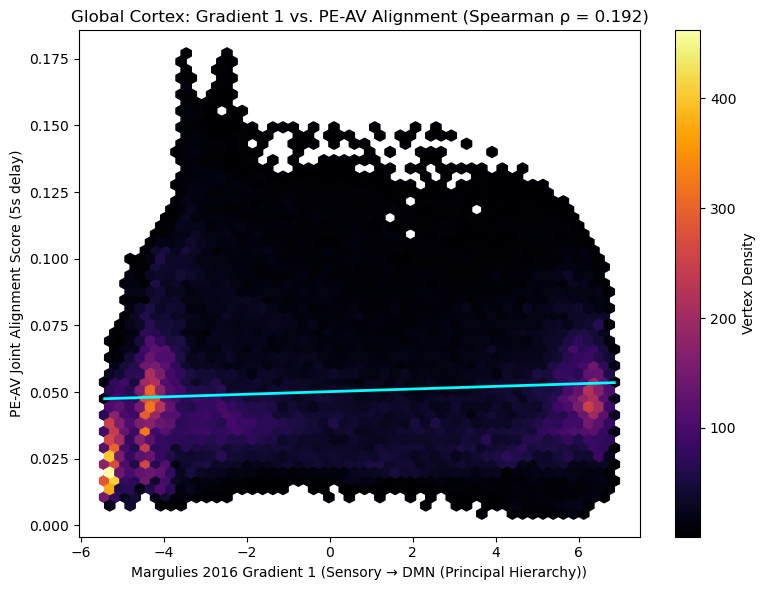

Processing Gradient 2...
Spearman Correlation (Global Cortex): ρ = 0.128, p = 4.440e-216


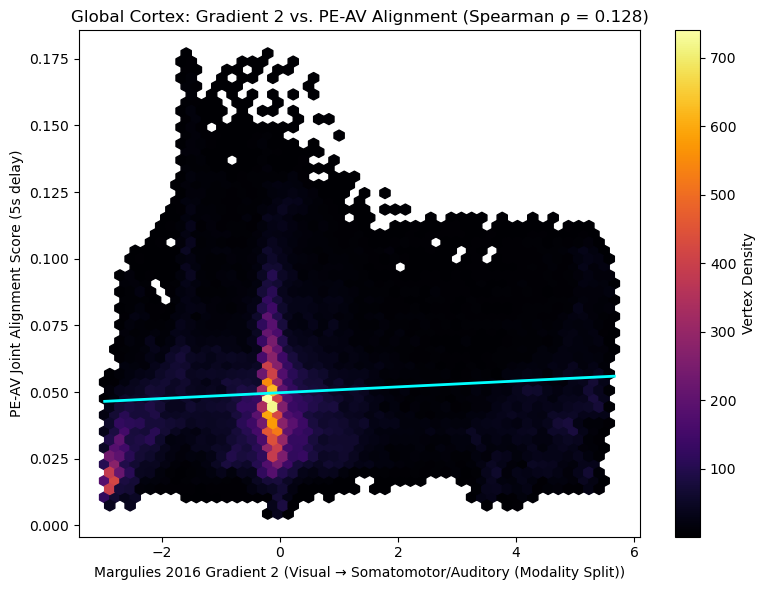

Processing Gradient 3...
Spearman Correlation (Global Cortex): ρ = -0.142, p = 2.573e-265


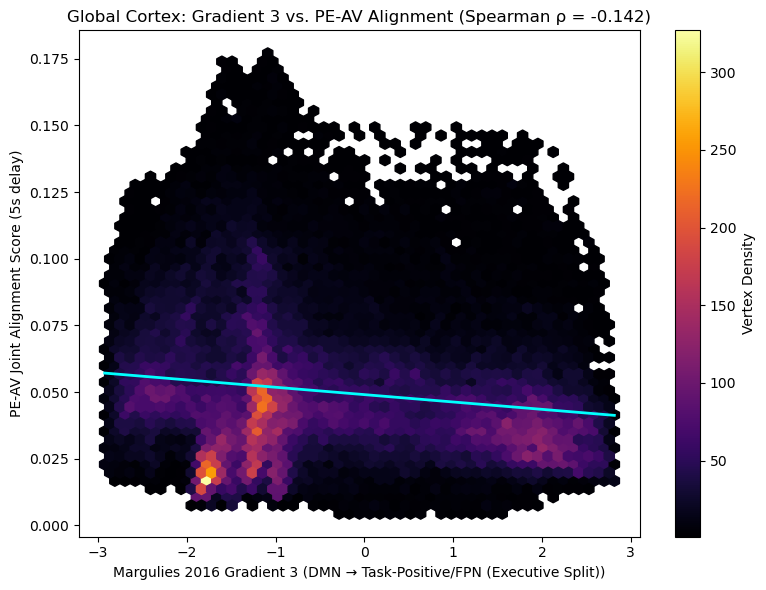

Processing Gradient 4...
Spearman Correlation (Global Cortex): ρ = 0.117, p = 6.509e-179


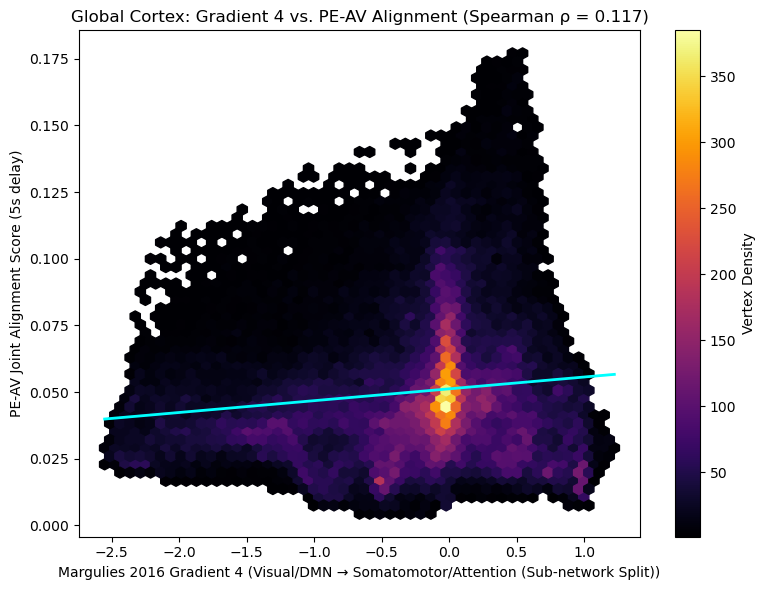

Processing Gradient 5...
Spearman Correlation (Global Cortex): ρ = 0.463, p = 0.000e+00


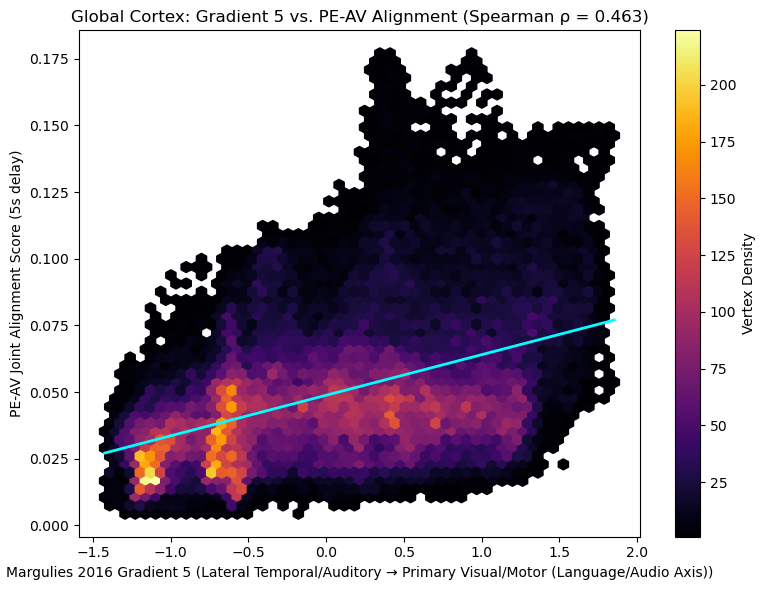

Processing Gradient 6...
Spearman Correlation (Global Cortex): ρ = -0.159, p = 0.000e+00


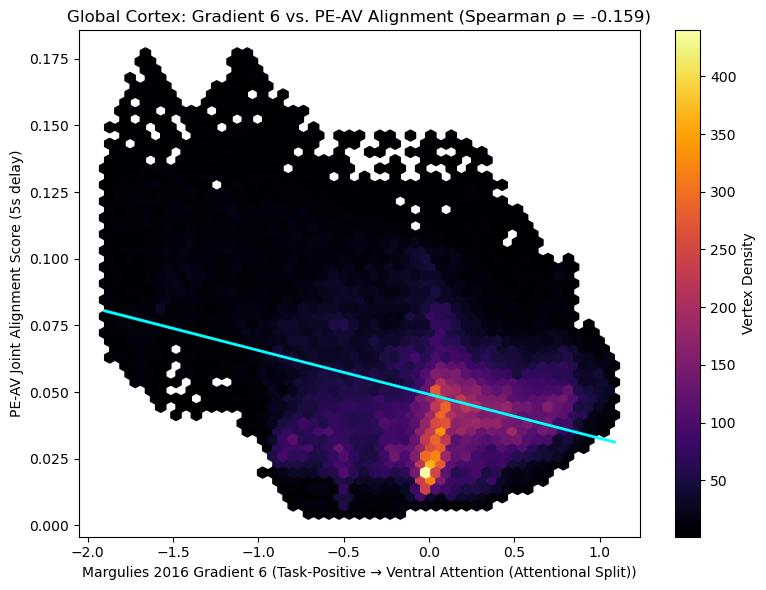

Processing Gradient 7...
Spearman Correlation (Global Cortex): ρ = -0.169, p = 0.000e+00


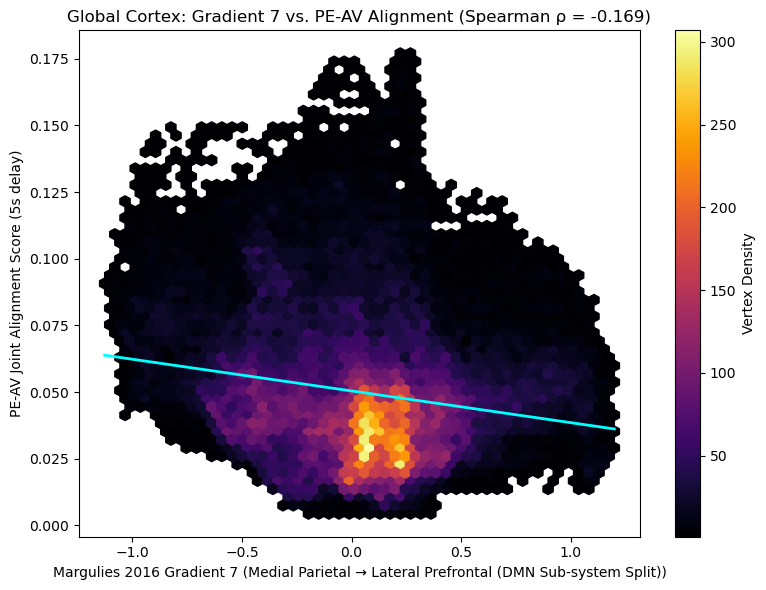

Processing Gradient 8...
Spearman Correlation (Global Cortex): ρ = 0.121, p = 2.306e-192


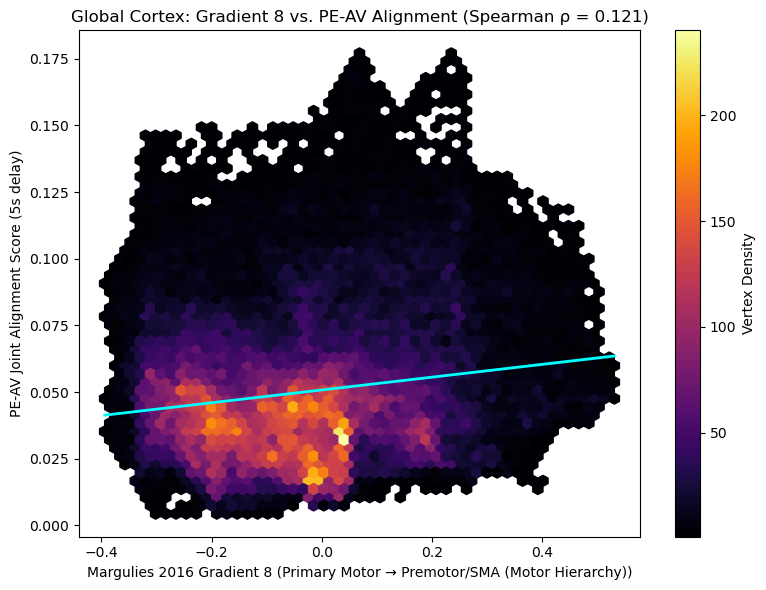

Processing Gradient 9...
Spearman Correlation (Global Cortex): ρ = -0.152, p = 2.092e-302


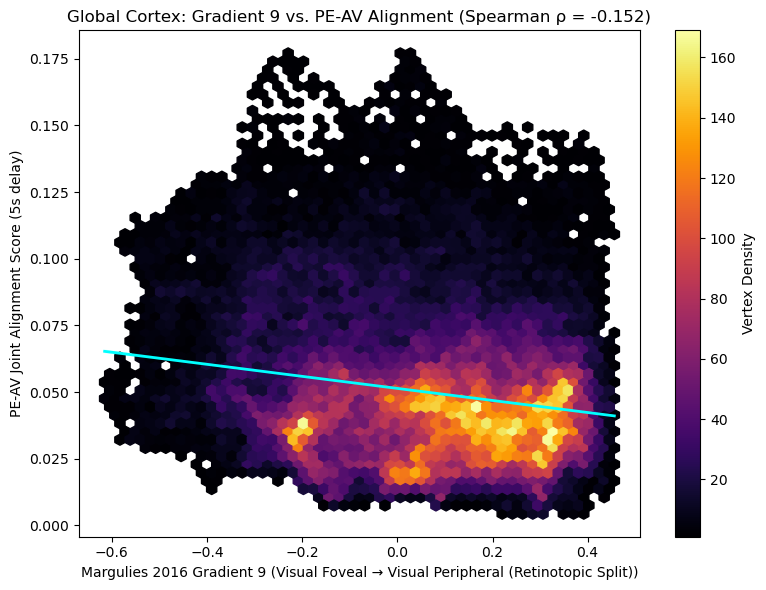

Processing Gradient 10...
Spearman Correlation (Global Cortex): ρ = -0.209, p = 0.000e+00


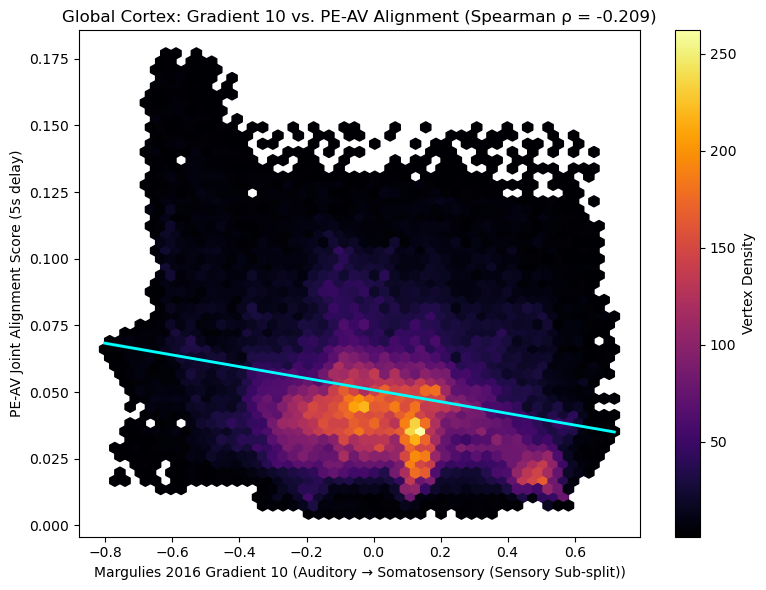

In [3]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr



# ---------------------------------------------------------
# 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
# ---------------------------------------------------------
left_npy_path = '/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_normalized_global_delay5s/2s/joint/left_hemisphere/rsa_pe-av-small-16-frame_joint_k100_spearman_normalized_nohrf_bin2s_left_global.npy'
right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

align_L_raw = np.load(left_npy_path)
align_R_raw = np.load(right_npy_path)

print(f"Loaded Left Alignment: {align_L_raw.shape[0]} vertices")
print(f"Loaded Right Alignment: {align_R_raw.shape[0]} vertices")

gradient_descriptions = {
    1: "Sensory → DMN (Principal Hierarchy)",
    2: "Visual → Somatomotor/Auditory (Modality Split)",
    3: "DMN → Task-Positive/FPN (Executive Split)",
    4: "Visual/DMN → Somatomotor/Attention (Sub-network Split)",
    5: "Lateral Temporal/Auditory → Primary Visual/Motor (Language/Audio Axis)",
    6: "Task-Positive → Ventral Attention (Attentional Split)",
    7: "Medial Parietal → Lateral Prefrontal (DMN Sub-system Split)",
    8: "Primary Motor → Premotor/SMA (Motor Hierarchy)",
    9: "Visual Foveal → Visual Peripheral (Retinotopic Split)",
    10: "Auditory → Somatosensory (Sensory Sub-split)"
}
for i in range(1, 11):
    
    print(f"Processing Gradient {i}...")
    # ---------------------------------------------------------
    # 2. LOAD LOCAL MARGULIES GRADIENTS (.gii)
    # ---------------------------------------------------------
    if i == 10:
        left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient10/fsLR/source-margulies2016_desc-fcgradient10_space-fsLR_den-32k_hemi-L_feature.func.gii'
    else:
        left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient0{i}/fsLR/source-margulies2016_desc-fcgradient0{i}_space-fsLR_den-32k_hemi-L_feature.func.gii'
    right_gii_path = left_gii_path.replace('hemi-L', 'hemi-R')

    grad1_L_raw = nib.load(left_gii_path).agg_data()
    grad1_R_raw = nib.load(right_gii_path).agg_data()

    # ---------------------------------------------------------
    # 3. GENERATE MEDIAL WALL MASKS & FILTER BOTH
    # ---------------------------------------------------------
    # We use the gradient to define where the medial wall is (NaNs or strict 0s)
    mask_L = (~np.isnan(grad1_L_raw)) & (grad1_L_raw != 0)
    mask_R = (~np.isnan(grad1_R_raw)) & (grad1_R_raw != 0)

    # Filter the gradients to cortex-only (~29k vertices)
    grad1_L_cortex = grad1_L_raw[mask_L]
    grad1_R_cortex = grad1_R_raw[mask_R]

    # Apply the exact same masks to your alignment NPYs
    align_L_cortex = align_L_raw[mask_L]
    align_R_cortex = align_R_raw[mask_R]

    # Check shapes
    assert grad1_L_cortex.shape == align_L_cortex.shape, "Left shape mismatch after masking!"
    assert grad1_R_cortex.shape == align_R_cortex.shape, "Right shape mismatch after masking!"

    # ---------------------------------------------------------
    # 4. CONCATENATE & CALCULATE CORRELATION
    # ---------------------------------------------------------
    grad1_full = np.concatenate([grad1_L_cortex, grad1_R_cortex])
    align_full = np.concatenate([align_L_cortex, align_R_cortex])

    # Final safety check for any NaNs originating from your alignment data itself
    valid_mask = ~np.isnan(align_full) & ~np.isnan(grad1_full)
    grad1_valid = grad1_full[valid_mask]
    align_valid = align_full[valid_mask]

    corr, p_val = spearmanr(grad1_valid, align_valid)
    print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

    # ---------------------------------------------------------
    # 5. CREATE THE SCATTERPLOT
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))

    plt.hexbin(grad1_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
    cb = plt.colorbar(label='Vertex Density')

    sns.regplot(x=grad1_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})
    axis_desc = gradient_descriptions.get(i, f"Variance Axis {i}")
    plt.xlabel(f'Margulies 2016 Gradient {i} ({axis_desc})')
    plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
    plt.title(f'Global Cortex: Gradient {i} vs. PE-AV Alignment (Spearman ρ = {corr:.3f})')

    plt.tight_layout()
    plt.show()

#### myelin

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Spearman Correlation (Global Cortex): ρ = -0.126, p = 1.499e-207


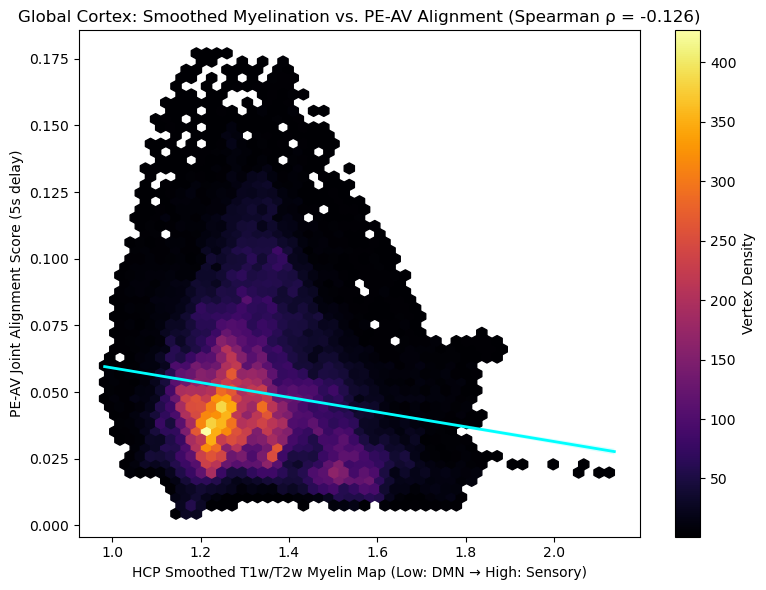

In [4]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# ---------------------------------------------------------
# 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
# ---------------------------------------------------------
left_npy_path = '/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_normalized_global_delay5s/2s/joint/left_hemisphere/rsa_pe-av-small-16-frame_joint_k100_spearman_normalized_nohrf_bin2s_left_global.npy'
right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

align_L_raw = np.load(left_npy_path)
align_R_raw = np.load(right_npy_path)

# ---------------------------------------------------------
# 2. LOAD YOUR SMOOTHED MYELIN CIFTI
# ---------------------------------------------------------
# MAKE SURE THIS PATH IS CORRECT FOR YOUR LOCAL MACHINE
myelin_cifti_path = '//home/amin/Research/Representation/Movie/data/Setareh/HCP_S1200_GroupAvg_v1/S1200.SmoothedMyelinMap_BC_MSMAll.32k_fs_LR.dscalar.nii'

myelin_cifti = nib.load(myelin_cifti_path)
myelin_data = myelin_cifti.get_fdata().squeeze()

# ---------------------------------------------------------
# 3. EXTRACT INDICES AND ALIGN SHAPES
# ---------------------------------------------------------
header = myelin_cifti.header
brain_models = header.get_index_map(1).brain_models

left_indices = None
right_indices = None

# Extract the exact valid cortical vertices from the CIFTI header
for bm in brain_models:
    if bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_LEFT':
        left_indices = np.array(bm.vertex_indices)
    elif bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
        right_indices = np.array(bm.vertex_indices)

# Filter your raw 32k alignment arrays down to the exact cortex vertices
align_L_cortex = align_L_raw[left_indices]
align_R_cortex = align_R_raw[right_indices]

# Combine them. CIFTI format strictly orders Left cortex then Right cortex.
align_full = np.concatenate([align_L_cortex, align_R_cortex])

# If the CIFTI has subcortical data (91k), we only want the cortex portion (first ~59k)
myelin_cortex = myelin_data[:len(align_full)]

# CRITICAL CHECK: Ensure shapes match perfectly
assert myelin_cortex.shape == align_full.shape, f"Shape mismatch! Myelin: {myelin_cortex.shape}, Align: {align_full.shape}"

# ---------------------------------------------------------
# 4. CALCULATE CORRELATION
# ---------------------------------------------------------
# Mask out any remaining NaNs originating from your alignment data
valid_mask = ~np.isnan(align_full) & ~np.isnan(myelin_cortex)
align_valid = align_full[valid_mask]
myelin_valid = myelin_cortex[valid_mask]

corr, p_val = spearmanr(myelin_valid, align_valid)
print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

# ---------------------------------------------------------
# 5. CREATE THE SCATTERPLOT
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.hexbin(myelin_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
cb = plt.colorbar(label='Vertex Density')

sns.regplot(x=myelin_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})

plt.xlabel('HCP Smoothed T1w/T2w Myelin Map (Low: DMN → High: Sensory)')
plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
plt.title(f'Global Cortex: Smoothed Myelination vs. PE-AV Alignment (Spearman ρ = {corr:.3f})')

plt.tight_layout()
plt.show()

## audio/video

Loaded Left Alignment: 32492 vertices
Loaded Right Alignment: 32492 vertices
Processing Gradient 1...
Spearman Correlation (Global Cortex): ρ = 0.332, p = 0.000e+00


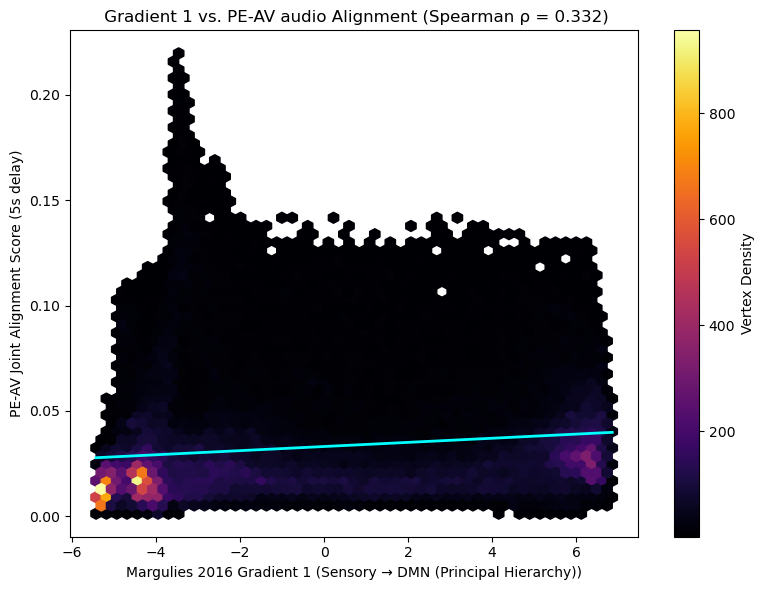

Processing Gradient 2...
Spearman Correlation (Global Cortex): ρ = -0.104, p = 1.006e-141


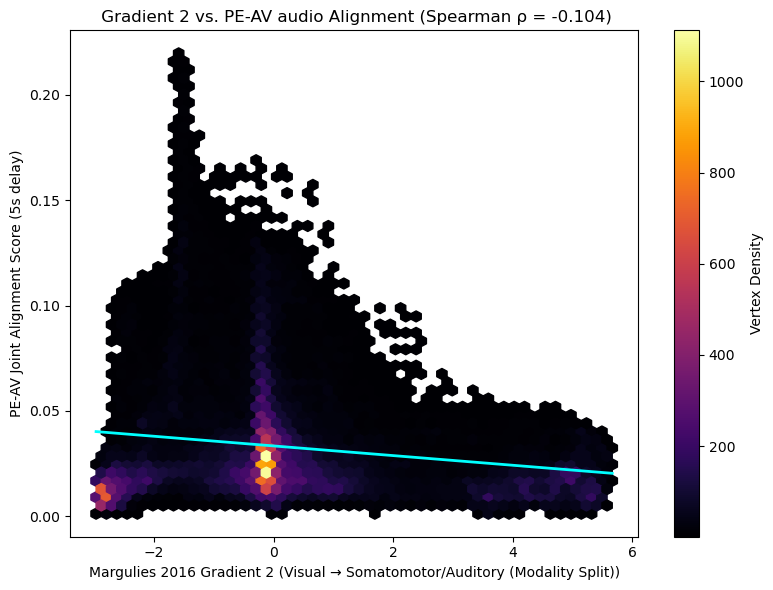

Processing Gradient 3...
Spearman Correlation (Global Cortex): ρ = -0.152, p = 1.253e-302


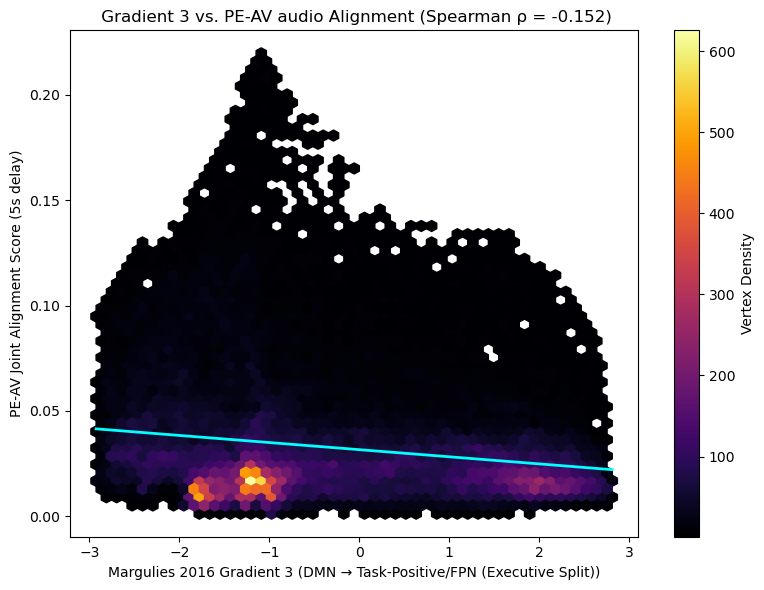

Processing Gradient 4...
Spearman Correlation (Global Cortex): ρ = 0.171, p = 0.000e+00


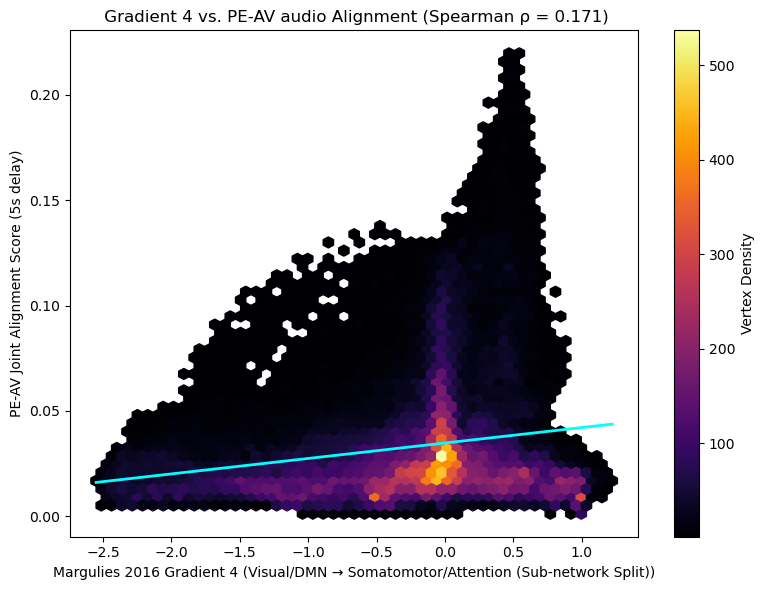

Processing Gradient 5...
Spearman Correlation (Global Cortex): ρ = 0.470, p = 0.000e+00


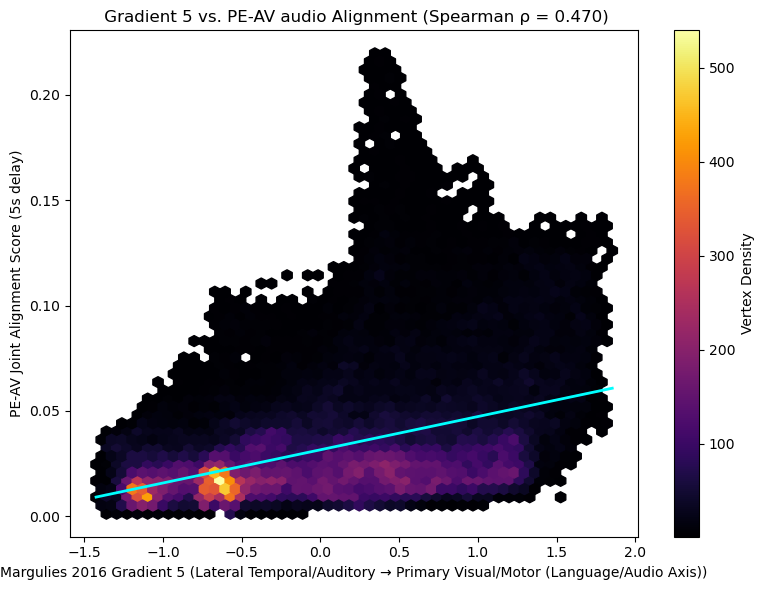

Processing Gradient 6...
Spearman Correlation (Global Cortex): ρ = -0.244, p = 0.000e+00


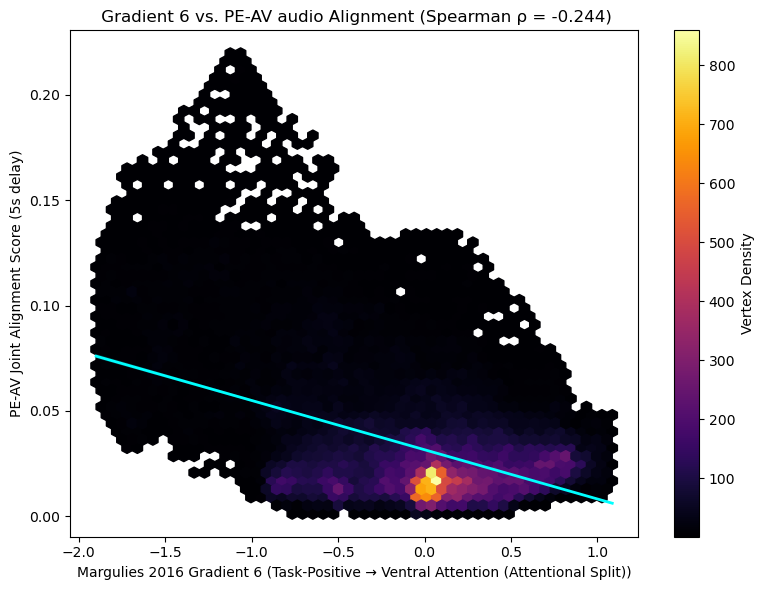

Processing Gradient 7...
Spearman Correlation (Global Cortex): ρ = -0.093, p = 2.290e-115


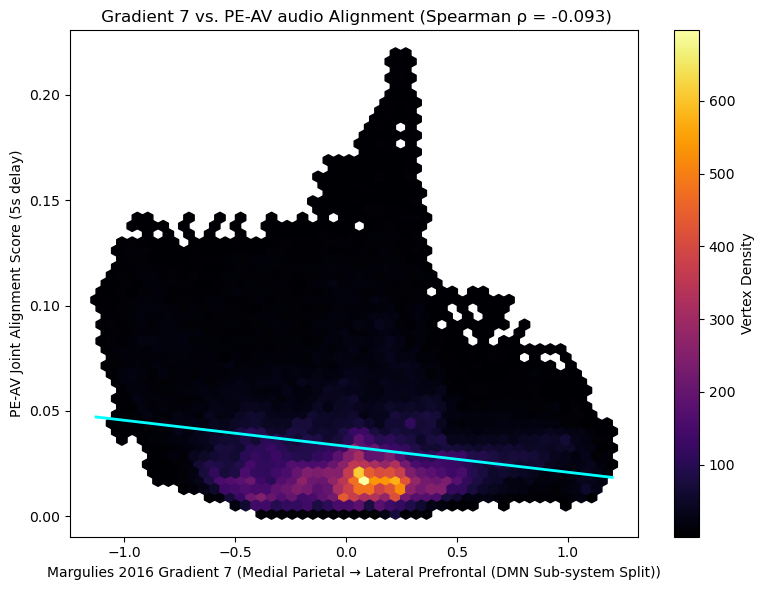

Processing Gradient 8...
Spearman Correlation (Global Cortex): ρ = -0.007, p = 7.314e-02


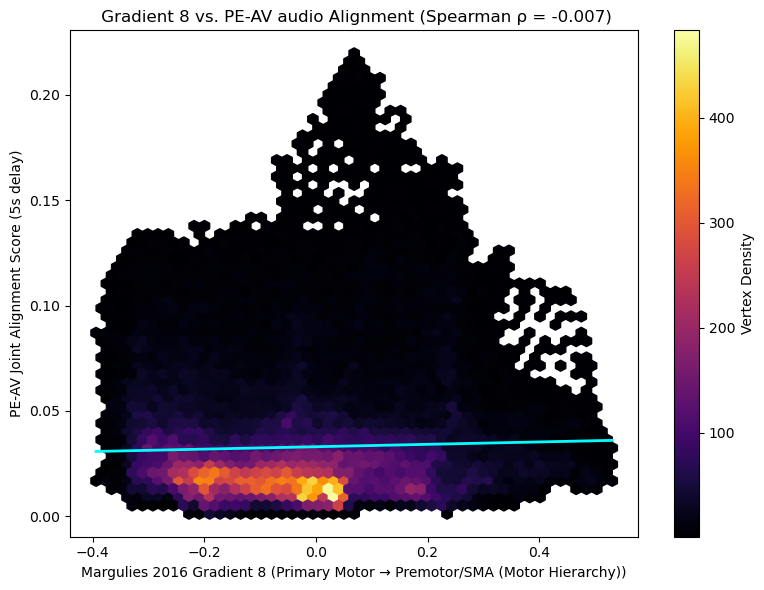

Processing Gradient 9...
Spearman Correlation (Global Cortex): ρ = 0.015, p = 2.481e-04


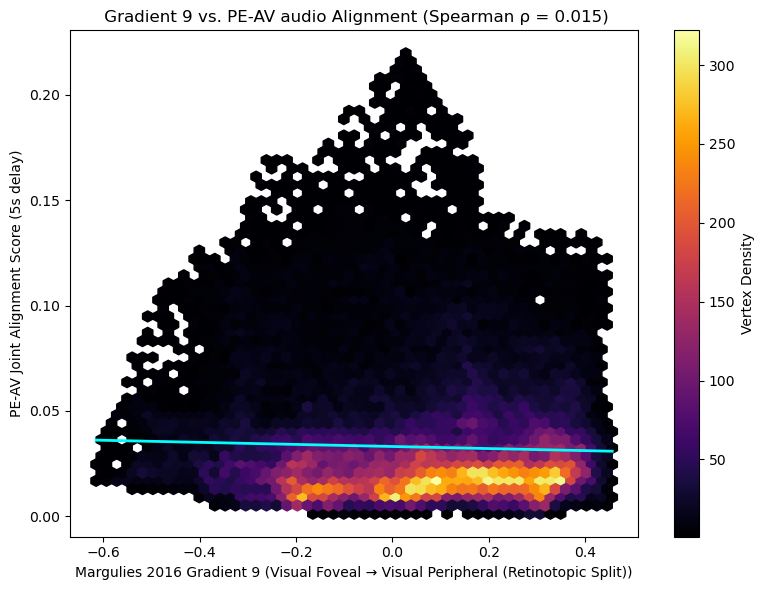

Processing Gradient 10...
Spearman Correlation (Global Cortex): ρ = -0.204, p = 0.000e+00


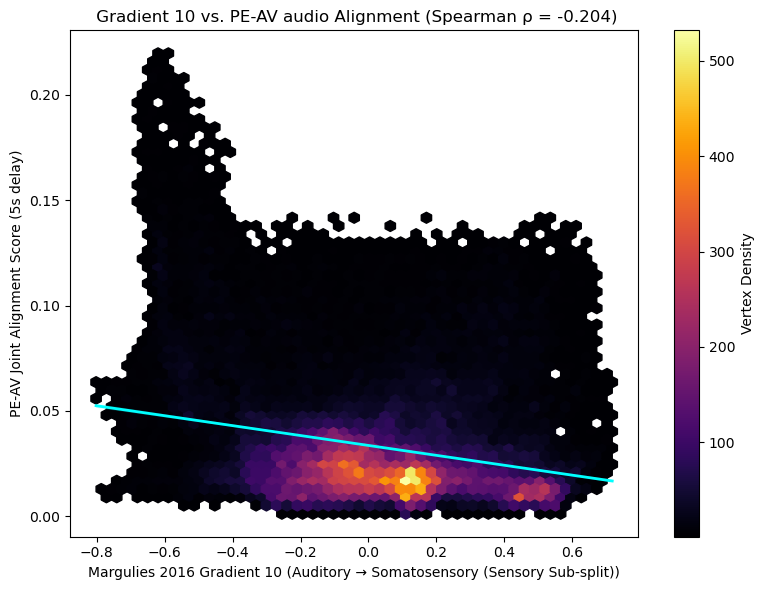

Loaded Left Alignment: 32492 vertices
Loaded Right Alignment: 32492 vertices
Processing Gradient 1...
Spearman Correlation (Global Cortex): ρ = 0.171, p = 0.000e+00


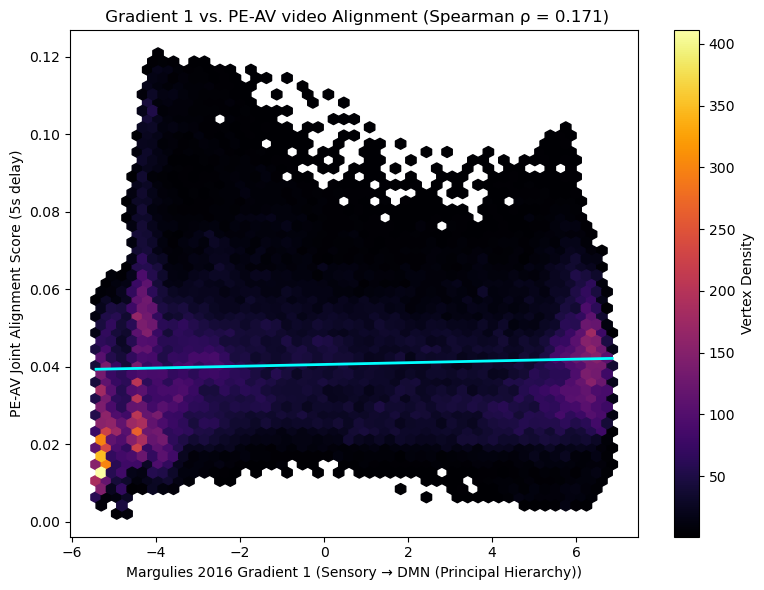

Processing Gradient 2...
Spearman Correlation (Global Cortex): ρ = 0.395, p = 0.000e+00


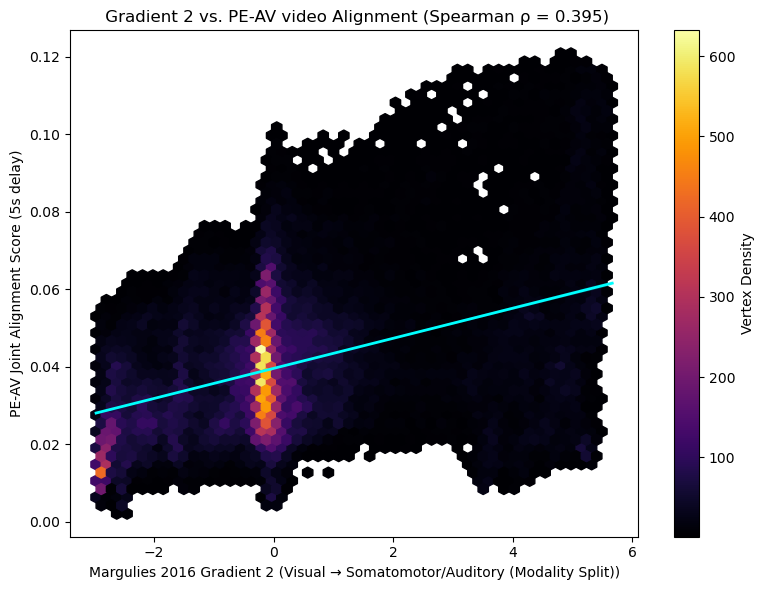

Processing Gradient 3...
Spearman Correlation (Global Cortex): ρ = -0.037, p = 1.157e-19


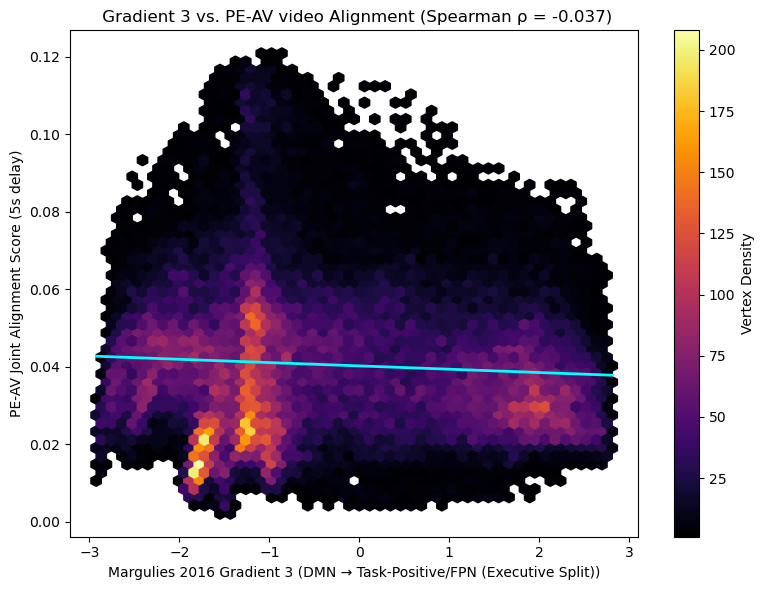

Processing Gradient 4...
Spearman Correlation (Global Cortex): ρ = -0.021, p = 1.637e-07


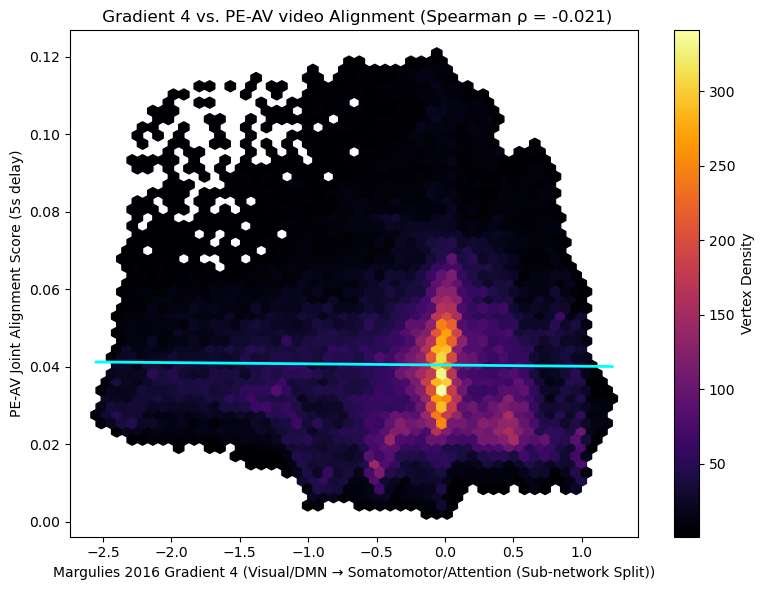

Processing Gradient 5...
Spearman Correlation (Global Cortex): ρ = 0.300, p = 0.000e+00


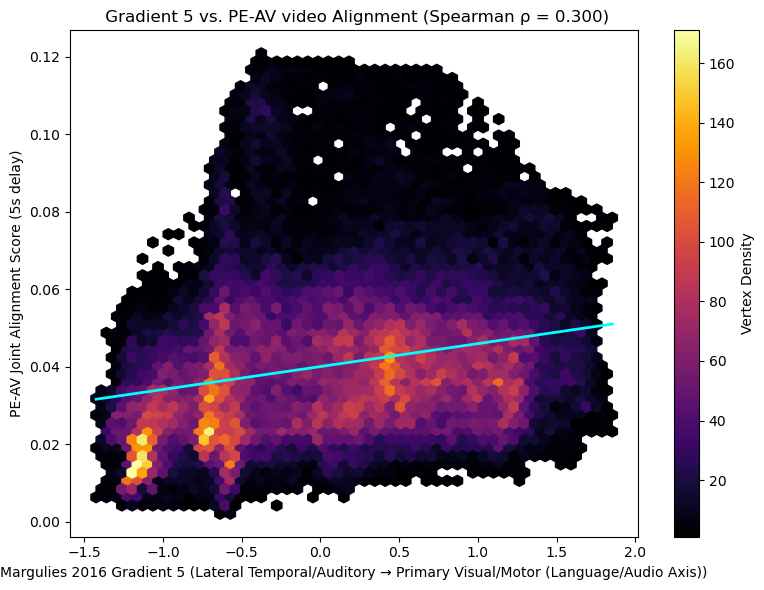

Processing Gradient 6...
Spearman Correlation (Global Cortex): ρ = 0.116, p = 3.148e-177


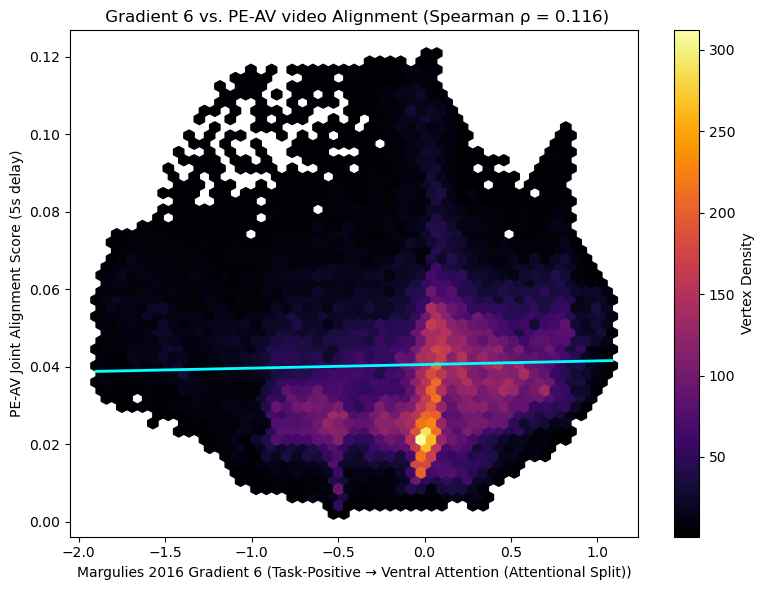

Processing Gradient 7...
Spearman Correlation (Global Cortex): ρ = -0.087, p = 3.217e-100


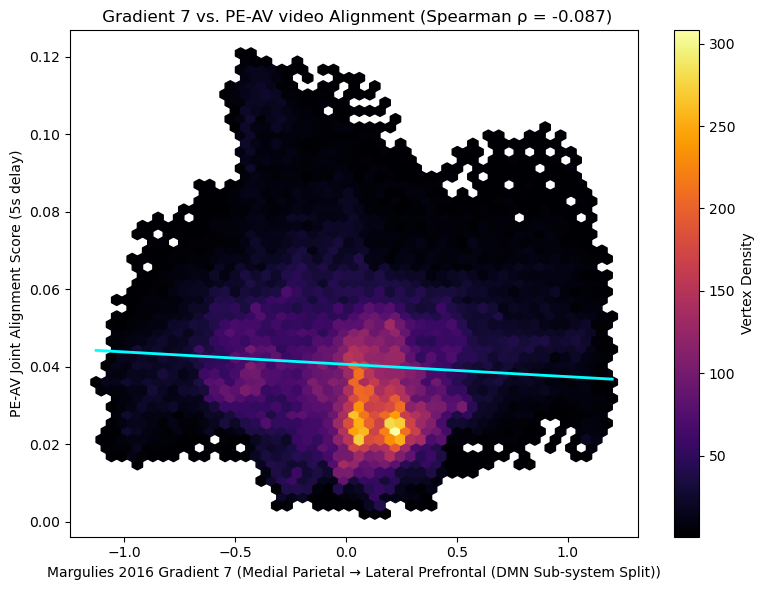

Processing Gradient 8...
Spearman Correlation (Global Cortex): ρ = 0.212, p = 0.000e+00


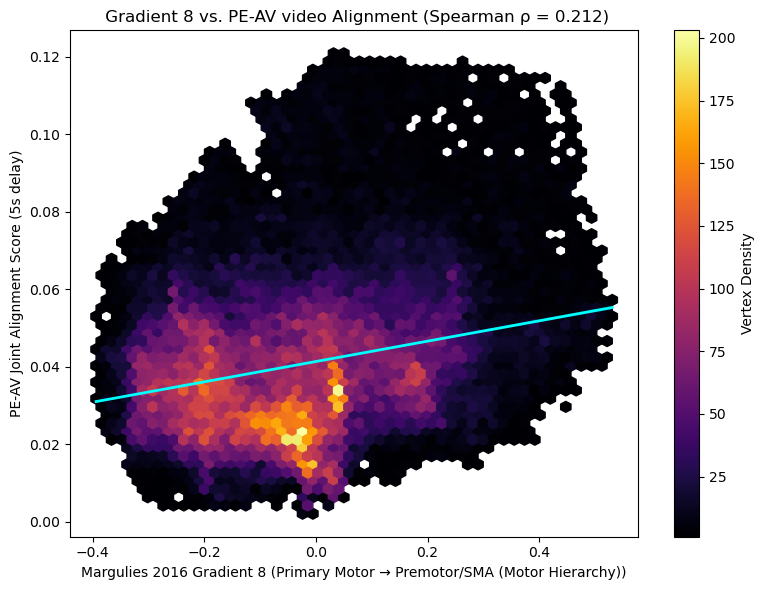

Processing Gradient 9...
Spearman Correlation (Global Cortex): ρ = -0.247, p = 0.000e+00


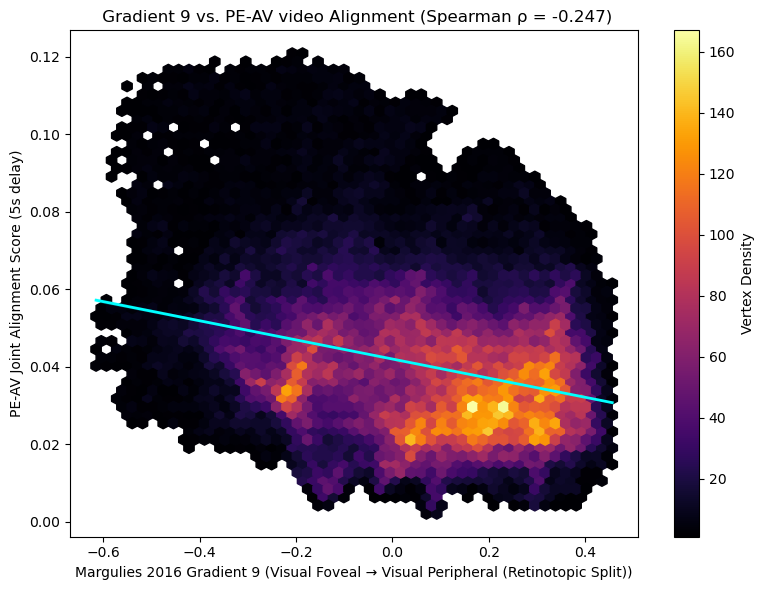

Processing Gradient 10...
Spearman Correlation (Global Cortex): ρ = -0.091, p = 5.133e-109


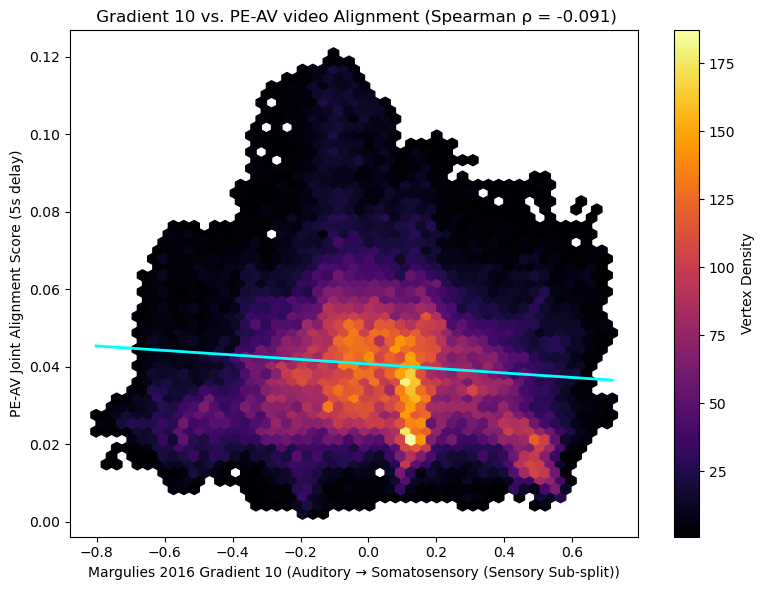

In [5]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr



modalities = ['audio' , 'video']
for modality in modalities:

    # ---------------------------------------------------------
    # 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
    # ---------------------------------------------------------
    left_npy_path = f'/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_normalized_global_delay5s/2s/{modality}/left_hemisphere/rsa_pe-av-small-16-frame_{modality}_k100_spearman_normalized_nohrf_bin2s_left_global.npy'
    right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

    align_L_raw = np.load(left_npy_path)
    align_R_raw = np.load(right_npy_path)

    print(f"Loaded Left Alignment: {align_L_raw.shape[0]} vertices")
    print(f"Loaded Right Alignment: {align_R_raw.shape[0]} vertices")

    gradient_descriptions = {
        1: "Sensory → DMN (Principal Hierarchy)",
        2: "Visual → Somatomotor/Auditory (Modality Split)",
        3: "DMN → Task-Positive/FPN (Executive Split)",
        4: "Visual/DMN → Somatomotor/Attention (Sub-network Split)",
        5: "Lateral Temporal/Auditory → Primary Visual/Motor (Language/Audio Axis)",
        6: "Task-Positive → Ventral Attention (Attentional Split)",
        7: "Medial Parietal → Lateral Prefrontal (DMN Sub-system Split)",
        8: "Primary Motor → Premotor/SMA (Motor Hierarchy)",
        9: "Visual Foveal → Visual Peripheral (Retinotopic Split)",
        10: "Auditory → Somatosensory (Sensory Sub-split)"
    }
    for i in range(1, 11):
        
        print(f"Processing Gradient {i}...")
        # ---------------------------------------------------------
        # 2. LOAD LOCAL MARGULIES GRADIENTS (.gii)
        # ---------------------------------------------------------
        if i == 10:
            left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient10/fsLR/source-margulies2016_desc-fcgradient10_space-fsLR_den-32k_hemi-L_feature.func.gii'
        else:
            left_gii_path = f'/home/amin/Research/Representation/Movie/data/margulies2016/fcgradient0{i}/fsLR/source-margulies2016_desc-fcgradient0{i}_space-fsLR_den-32k_hemi-L_feature.func.gii'
        right_gii_path = left_gii_path.replace('hemi-L', 'hemi-R')

        grad1_L_raw = nib.load(left_gii_path).agg_data()
        grad1_R_raw = nib.load(right_gii_path).agg_data()

        # ---------------------------------------------------------
        # 3. GENERATE MEDIAL WALL MASKS & FILTER BOTH
        # ---------------------------------------------------------
        # We use the gradient to define where the medial wall is (NaNs or strict 0s)
        mask_L = (~np.isnan(grad1_L_raw)) & (grad1_L_raw != 0)
        mask_R = (~np.isnan(grad1_R_raw)) & (grad1_R_raw != 0)

        # Filter the gradients to cortex-only (~29k vertices)
        grad1_L_cortex = grad1_L_raw[mask_L]
        grad1_R_cortex = grad1_R_raw[mask_R]

        # Apply the exact same masks to your alignment NPYs
        align_L_cortex = align_L_raw[mask_L]
        align_R_cortex = align_R_raw[mask_R]

        # Check shapes
        assert grad1_L_cortex.shape == align_L_cortex.shape, "Left shape mismatch after masking!"
        assert grad1_R_cortex.shape == align_R_cortex.shape, "Right shape mismatch after masking!"

        # ---------------------------------------------------------
        # 4. CONCATENATE & CALCULATE CORRELATION
        # ---------------------------------------------------------
        grad1_full = np.concatenate([grad1_L_cortex, grad1_R_cortex])
        align_full = np.concatenate([align_L_cortex, align_R_cortex])

        # Final safety check for any NaNs originating from your alignment data itself
        valid_mask = ~np.isnan(align_full) & ~np.isnan(grad1_full)
        grad1_valid = grad1_full[valid_mask]
        align_valid = align_full[valid_mask]

        corr, p_val = spearmanr(grad1_valid, align_valid)
        print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

        # ---------------------------------------------------------
        # 5. CREATE THE SCATTERPLOT
        # ---------------------------------------------------------
        plt.figure(figsize=(8, 6))

        plt.hexbin(grad1_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
        cb = plt.colorbar(label='Vertex Density')

        sns.regplot(x=grad1_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})
        axis_desc = gradient_descriptions.get(i, f"Variance Axis {i}")
        plt.xlabel(f'Margulies 2016 Gradient {i} ({axis_desc})')
        plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
        plt.title(f' Gradient {i} vs. PE-AV {modality} Alignment (Spearman ρ = {corr:.3f})')

        plt.tight_layout()
        plt.show()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Spearman Correlation (Global Cortex): ρ = -0.224, p = 0.000e+00


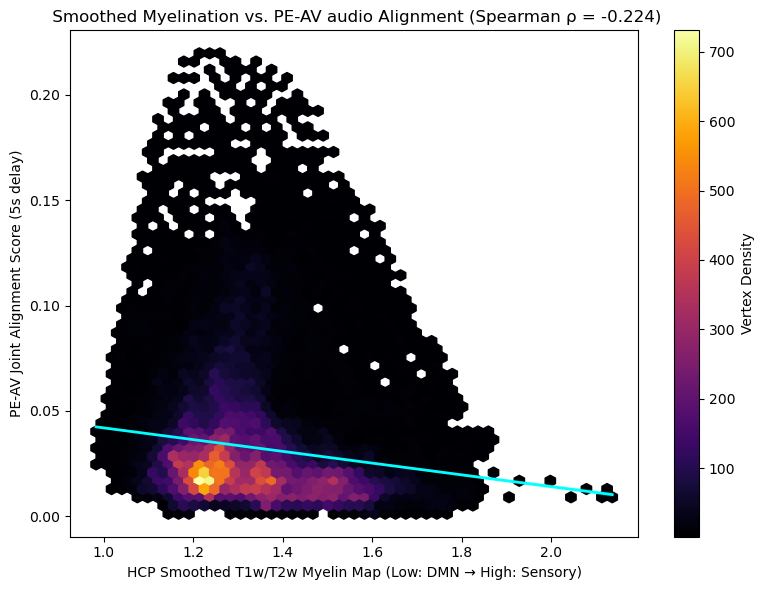

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Spearman Correlation (Global Cortex): ρ = -0.101, p = 1.320e-135


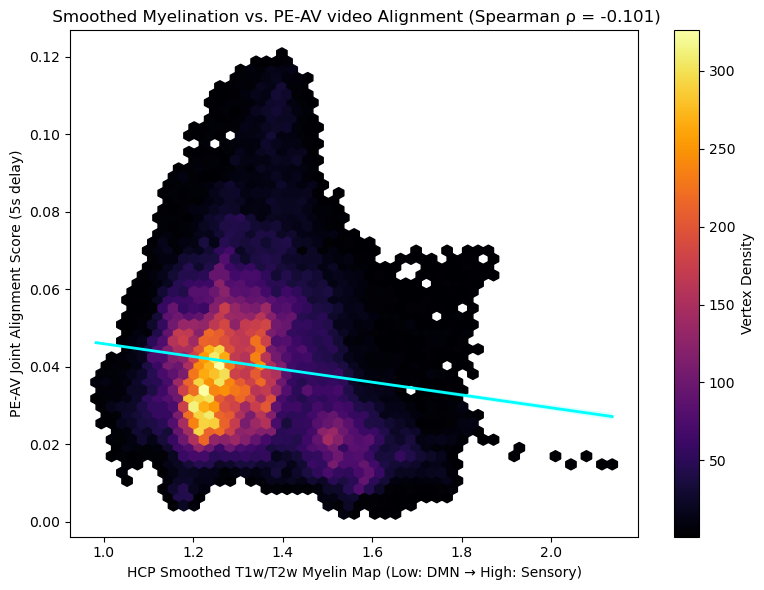

In [6]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


modalities = ['audio' , 'video']
for modality in modalities:

    # ---------------------------------------------------------
    # 1. LOAD YOUR ALIGNMENT RESULTS (.npy)
    # ---------------------------------------------------------
    left_npy_path = f'/home/amin/Research/Representation/Movie/outputs/searchlight_rsa_output/pe-av-small-16-frame/k100_normalized_global_delay5s/2s/{modality}/left_hemisphere/rsa_pe-av-small-16-frame_{modality}_k100_spearman_normalized_nohrf_bin2s_left_global.npy'
    right_npy_path = left_npy_path.replace('left_hemisphere', 'right_hemisphere').replace('_left_global', '_right_global')

    align_L_raw = np.load(left_npy_path)
    align_R_raw = np.load(right_npy_path)

    # ---------------------------------------------------------
    # 2. LOAD YOUR SMOOTHED MYELIN CIFTI
    # ---------------------------------------------------------
    # MAKE SURE THIS PATH IS CORRECT FOR YOUR LOCAL MACHINE
    myelin_cifti_path = f'/home/amin/Research/Representation/Movie/data/Setareh/HCP_S1200_GroupAvg_v1/S1200.SmoothedMyelinMap_BC_MSMAll.32k_fs_LR.dscalar.nii'

    myelin_cifti = nib.load(myelin_cifti_path)
    myelin_data = myelin_cifti.get_fdata().squeeze()

    # ---------------------------------------------------------
    # 3. EXTRACT INDICES AND ALIGN SHAPES
    # ---------------------------------------------------------
    header = myelin_cifti.header
    brain_models = header.get_index_map(1).brain_models

    left_indices = None
    right_indices = None

    # Extract the exact valid cortical vertices from the CIFTI header
    for bm in brain_models:
        if bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_LEFT':
            left_indices = np.array(bm.vertex_indices)
        elif bm.brain_structure == 'CIFTI_STRUCTURE_CORTEX_RIGHT':
            right_indices = np.array(bm.vertex_indices)

    # Filter your raw 32k alignment arrays down to the exact cortex vertices
    align_L_cortex = align_L_raw[left_indices]
    align_R_cortex = align_R_raw[right_indices]

    # Combine them. CIFTI format strictly orders Left cortex then Right cortex.
    align_full = np.concatenate([align_L_cortex, align_R_cortex])

    # If the CIFTI has subcortical data (91k), we only want the cortex portion (first ~59k)
    myelin_cortex = myelin_data[:len(align_full)]

    # CRITICAL CHECK: Ensure shapes match perfectly
    assert myelin_cortex.shape == align_full.shape, f"Shape mismatch! Myelin: {myelin_cortex.shape}, Align: {align_full.shape}"

    # ---------------------------------------------------------
    # 4. CALCULATE CORRELATION
    # ---------------------------------------------------------
    # Mask out any remaining NaNs originating from your alignment data
    valid_mask = ~np.isnan(align_full) & ~np.isnan(myelin_cortex)
    align_valid = align_full[valid_mask]
    myelin_valid = myelin_cortex[valid_mask]

    corr, p_val = spearmanr(myelin_valid, align_valid)
    print(f"Spearman Correlation (Global Cortex): ρ = {corr:.3f}, p = {p_val:.3e}")

    # ---------------------------------------------------------
    # 5. CREATE THE SCATTERPLOT
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))

    plt.hexbin(myelin_valid, align_valid, gridsize=50, cmap='inferno', mincnt=1)
    cb = plt.colorbar(label='Vertex Density')

    sns.regplot(x=myelin_valid, y=align_valid, scatter=False, color='cyan', line_kws={"linewidth": 2})

    plt.xlabel('HCP Smoothed T1w/T2w Myelin Map (Low: DMN → High: Sensory)')
    plt.ylabel('PE-AV Joint Alignment Score (5s delay)')
    plt.title(f' Smoothed Myelination vs. PE-AV {modality} Alignment (Spearman ρ = {corr:.3f})')

    plt.tight_layout()
    plt.show()